<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/prac2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pandas.core import frame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
housing_raw="https://raw.githubusercontent.com/ageron/handson-ml/master/"
housing=pd.read_csv(housing_raw+"datasets/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


total_bedroom =20433 out of 20640(missing 207) also ocean_proxity is object type.We will use Imputer(for total bedrooms) and ordinalEncoder(for ocean proximity)

In [5]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Higher std deviation --->median_housing_value,households,total_rooms,population

In [7]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


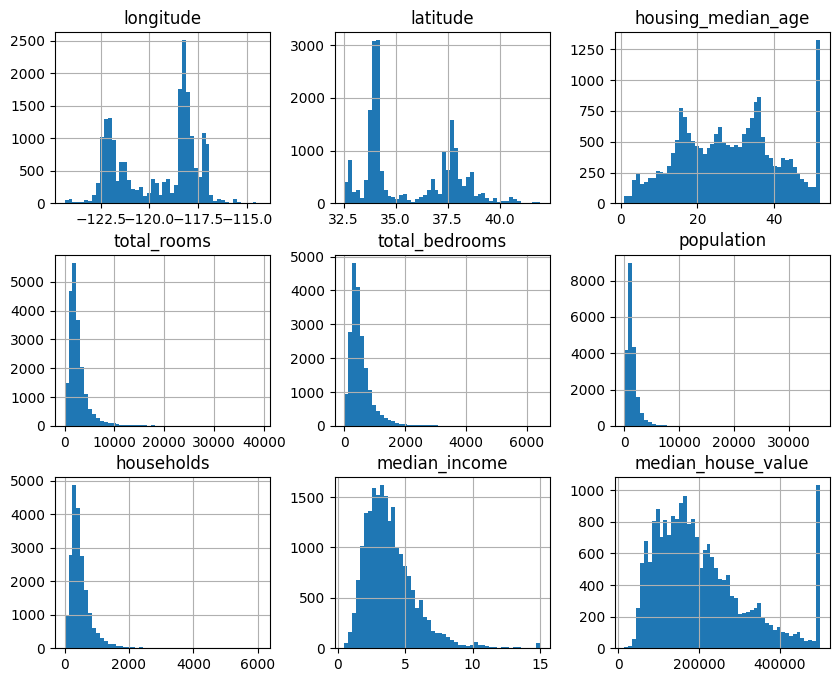

In [8]:
housing.hist(bins=50,figsize=(10,8))
plt.show()

## `Ocean-proximity` categorical data handling

In [29]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
housing_num = housing.drop("ocean_proximity", axis=1)
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing[['ocean_proximity']])
housing_cat_df = pd.DataFrame(housing_cat_encoded, columns=['ocean_proximity_encoded'], index=housing.index)

# Combine the numerical features and the encoded categorical feature
housing_final = pd.concat([housing_num, housing_cat_df], axis=1)

# Display the first few rows of the new complete DataFrame
housing_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


Now ocean_proximity is converted to numerical data

## `total_bedrooms` missing value handling

### Handling Missing Values in `total_bedrooms`

As noted earlier, the `total_bedrooms` column has 207 missing values. We will use `sklearn.impute.SimpleImputer` to fill these missing values with the median of the column. The median is chosen because it is more robust to outliers than the mean.

In [41]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_final)
X = imputer.transform(housing_final)
housing_final = pd.DataFrame(X, columns=housing_final.columns, index=housing_final.index)
housing_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


## `standardizing data`

In [62]:
for col_name in housing_final.columns:
    print(f"variance of {col_name} is {np.var(housing_final[col_name])}")


variance of longitude is 4.013944883584757
variance of latitude is 4.562071602892503
variance of housing_median_age is 158.3885861703583
variance of total_rooms is 4759214.51266799
variance of total_bedrooms is 175881.02548628923
variance of population is 1282408.3220366791
variance of households is 146168.95772780414
variance of median_income is 3.60914768969746
variance of median_house_value is 13315503000.817923
variance of ocean_proximity_encoded is 2.018184076133487


We can see that the data point is not standarized so we will try standardized the data(i.e variance to 1)

In [64]:
from sklearn.preprocessing import StandardScaler

# Separate the features (inputs) from the target (output)
# We typically don't scale the target variable
housing_features = housing_final.drop("median_house_value", axis=1)
housing_labels = housing_final["median_house_value"].copy()

# Initialize and apply the StandardScaler
scaler = StandardScaler()
housing_scaled_array = scaler.fit_transform(housing_features)

# Convert back to a DataFrame for easier viewing
housing_prepared = pd.DataFrame(
    housing_scaled_array,
    columns=housing_features.columns,
    index=housing_features.index
)


In [65]:
for col_name in housing_prepared.columns:
    print(f"variance of {col_name} is {np.var(housing_prepared[col_name])}")


variance of longitude is 0.9999999999999907
variance of latitude is 0.9999999999999811
variance of housing_median_age is 1.0000000000000362
variance of total_rooms is 0.9999999999999964
variance of total_bedrooms is 1.000000000000005
variance of population is 0.9999999999999967
variance of households is 0.9999999999999848
variance of median_income is 0.9999999999999964
variance of ocean_proximity_encoded is 0.9999999999997499


In [66]:
housing_prepared.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_encoded
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-9.363741e-17,-1.101617e-17,6.885104e-17,6.609700e-17,-5.508083e-18
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-8.206532e-01
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-8.206532e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-1.167392e-01
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,-1.167392e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,1.995003e+00


### Feature Scaling

Machine Learning algorithms don't perform well when the input numerical attributes have very different scales. For instance, the `total_rooms` and `median_income` are on different scales. To address this, we need to apply **Feature Scaling**.

Two common ways to get all attributes to have the same scale are Min-Max scaling (Normalization) and Standardization. Here, we will use **Standardization** (using `StandardScaler`), which is less affected by outliers than Min-Max scaling.